In [122]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import numpy as np
from math import cos, sin
%matplotlib inline

face3d = np.load('f3d_68_pts.npy')
print(face3d.shape)

(3, 68)


Text(0.5, 0.92, 'Figure 1: 3D Facial Landmarks')

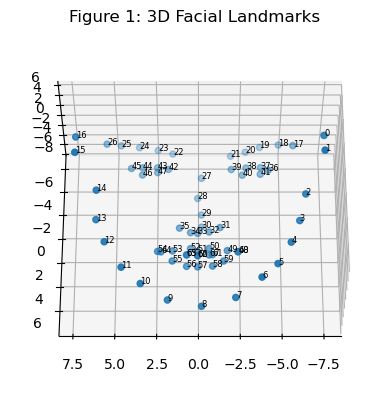

In [119]:
# TODO 1: Draw the 3D facial landmarks.
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.view_init(elev=60, azim=90)    # 設定仰角和方位角
ax.set_box_aspect((2, 1.5, 1))    # 調整座標軸框的縱橫比

x = face3d[0, :]
y = face3d[1, :]
z = face3d[2, :]

ax.scatter3D(x, y, z)

for i in range(face3d.shape[1]):
    ax.text(x[i], y[i], z[i], str(i), fontsize=6)

ax.set_title('Figure 1: 3D Facial Landmarks')

# 參考資料：https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.12-Three-Dimensional-Plotting.ipynb
# 參考資料：https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_box_aspect.html

In [121]:
# TODO 2: Computer the Euclidean distance between inner eyes.
p1 = face3d[:, 39]
p2 = face3d[:, 42]
dist = np.sqrt(np.sum((p1 - p2)**2))
print(f"The Euclidean distance between the inner eyes is: %.2f" %dist)

The Euclidean distance between the inner eyes is: 3.84


Text(0.5, 1.0, 'Figure 3: 2D Projected Landmarks')

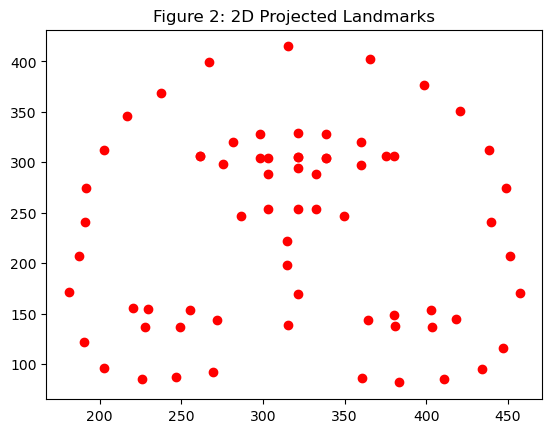

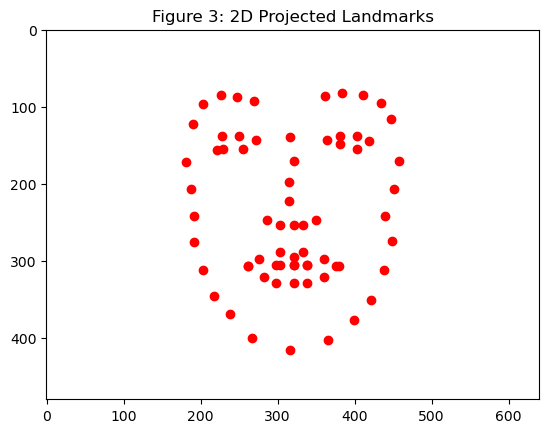

In [80]:
# TODO 3: 3D-to-2D Projection.

# Step 3.1: Construct the intrinsic matrix K.
K = np.array([[640, 0, 320],
              [0, 640, 240],
              [0,   0,   1]])       # f = 640，principal point = (320, 240)

# Step 3.2: Contruct the extrinsic matrix [R,t].
R = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]])       # The camera didn't rotate.
t = np.array([[0], [0], [30]])  # Relative distance between camera and object
extrinsic = np.hstack((R, t))   # Horizontal merging

# Step 3.3: Construct the 2D projection matrix m.
M_World_H = np.vstack((face3d, np.ones((1, face3d.shape[1]))))    # Homogeneous Coordinates
m_Img_H = K @ extrinsic @ M_World_H    # Matrix Mult
m = m_Img_H[:2, :] / m_Img_H[2, :]     # Homogeneous to Rectangular

# Step 3.4: Plot matrix m.
plt.figure()
plt.plot(m[0, :], m[1, :], 'ro') 
plt.title('Figure 2: 2D Projected Landmarks')

# Step 3.5: Plot matrix m with imshow.
plt.figure()
white_image = np.full((480,640,3),255)
plt.imshow(white_image)
plt.plot(m[0, :], m[1, :], 'ro') 
plt.title('Figure 3: 2D Projected Landmarks')

## Question 1: Why is the orientation of the face in Figure 2 different from that in Figure 3?
因為僅使用`plt.plot`時，Matplotlib預設採用直角座標系，所以**原點在左下方**，$y$ 軸是向上遞增。\
當加入`plt.imshow`時，坐標系會切換成影像坐標系，**原點在左上方**，$y$ 軸是向下遞增。

Text(0.5, 1.0, 'Case 2')

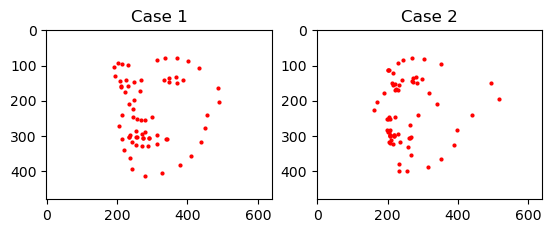

In [123]:
# TODO 4: Repeat Steps 3.1, 3.2, 3.3, 3.5 with different rotation matrices.
def project_face(pts, alpha, beta, gamma):
    # deg2rad
    a = np.radians(alpha)
    b = np.radians(beta)
    g = np.radians(gamma)
    
    Rz = np.array([[cos(a), -sin(a),   0],
                   [sin(a),  cos(a),   0],
                   [0,            0,   1]])
    
    Ry = np.array([[cos(b),     0,    sin(b)],
                   [0,          1,         0],
                   [-sin(b),    0,    cos(b)]])
    
    Rx = np.array([[1,        0,         0],
                   [0,   cos(g),   -sin(g)],
                   [0,   sin(g),    cos(g)]])
    
    R = Rz @ Ry @ Rx
    extrinsic = np.hstack((R, t))   

    M_World_H = np.vstack((pts, np.ones((1, pts.shape[1])))) 
    m_Img_H = K @ extrinsic @ M_World_H    
    m = m_Img_H[:2, :] / m_Img_H[2, :]

    return m
    

m1 = project_face(face3d, 0, 20, 0)
m2 = project_face(face3d, 0, 60, 0)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(white_image)
ax1.plot(m1[0, :], m1[1, :], 'ro', markersize=2)
ax1.set_title('Case 1')

ax2.imshow(white_image)
ax2.plot(m2[0, :], m2[1, :], 'ro', markersize=2)
ax2.set_title('Case 2')

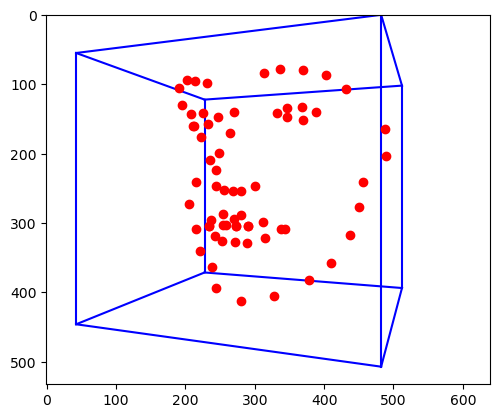

In [117]:
# TODO 5: Augmented Reality

# Step 5.1: Construct the eight vertices of the cube containing the 3D facial landmarks
xmin, xmax = np.min(face3d[0, :]) - 1, np.max(face3d[0, :]) + 1
ymin, ymax = np.min(face3d[1, :]) - 1, np.max(face3d[1, :]) + 1
zmin, zmax = np.min(face3d[2, :]) - 1, np.max(face3d[2, :]) + 1

cube_pts = np.array([
    [xmin, ymin, zmin], # 0
    [xmax, ymin, zmin], # 1
    [xmax, ymax, zmin], # 2
    [xmin, ymax, zmin], # 3
    [xmin, ymin, zmax], # 4
    [xmax, ymin, zmax], # 5
    [xmax, ymax, zmax], # 6
    [xmin, ymax, zmax]  # 7
]).T

# Step 5.2: Follow TODO 4 to project the 3D facial landmarks and the eight vertices of the cube onto the 2D space.

m1 = project_face(face3d, 0, 20, 0)
m_cube = project_face(cube_pts, 0, 20, 0)


edges = [
    (0,1), (1,2), (2,3), (3,0), # 底面
    (4,5), (5,6), (6,7), (7,4), # 頂面
    (0,4), (1,5), (2,6), (3,7)  # 側面垂直邊
]

plt.figure()
white_image = np.full((480,640,3),255)
for start, end in edges:
    plt.plot([m_cube[0, start], m_cube[0, end]], 
             [m_cube[1, start], m_cube[1, end]], 'b-')


plt.imshow(white_image)
plt.plot(m1[0, :], m1[1, :], 'ro')